# Stroke Risk Analysis: Identifying the Top Predictors Using Logistic Regression

## Import required libraries

In [59]:
# classification model to identify the top predictors of stroke.

import pandas as pd #used to load and manipulate the dataset.
import numpy as np #used for numerical operations (like exponentiation for odds ratios).

from sklearn.model_selection import train_test_split
#preprocessing tools:
from sklearn.compose import ColumnTransformer #scale numeric columns.
from sklearn.preprocessing import OneHotEncoder #convert categorcal features to numeric.
from sklearn.preprocessing import StandardScaler #standardize numeric features.
from sklearn.pipeline import Pipeline #combine preprocessing steps and model into a single pipeline.
from sklearn.impute import SimpleImputer #fill median values for missing numeric data(BMI).
#metrics for evaluating model performance:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
#models:
from sklearn.linear_model import LogisticRegression 
#visualization:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import ConfusionMatrixDisplay


## Load Dataset

In [60]:
df = pd.read_csv('data/stroke_dataset.csv')

In [61]:
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Class imbalance visualization

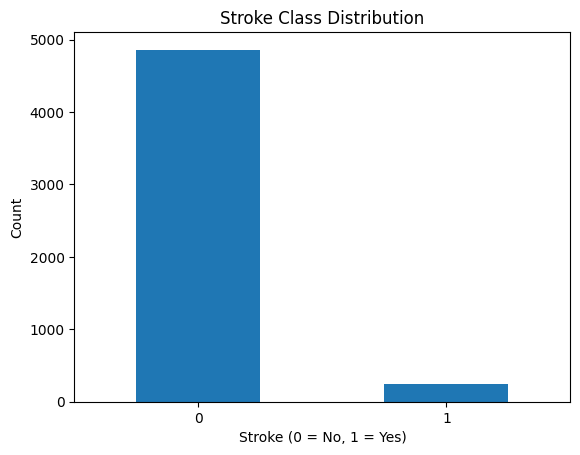

Percentage distribution:
stroke
0    95.13
1     4.87
Name: count, dtype: float64


In [62]:
#class distribution of the target variable (stroke) to understand the imbalance in the dataset.
stroke_counts = df["stroke"].value_counts()

plt.figure()
stroke_counts.plot(kind="bar")
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("Percentage distribution:")
print((stroke_counts / len(df) * 100).round(2))

In [63]:
# Separate predictors (X) from target label (y = stroke)
target = "stroke"
X = df.drop(columns=[target]) #predictor variables (features).
y = df[target] #target variable (stroke).

In [64]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (5110, 11)
Target vector shape: (5110,)

Target distribution:
stroke
0    4861
1     249
Name: count, dtype: int64


In [65]:
# Define feature groups by data type.

num_cols = ["age", "avg_glucose_level", "bmi"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
bin_cols = ["hypertension", "heart_disease"]  # already numeric but keep them in num pipeline or pass-through

## Train/Test Split

In [66]:
# Split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

In [67]:
# # Build preprocessing pipelines for numeric and categorical features.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric and categorical transformers into a single ColumnTransformer.
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols + bin_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


In [68]:


# 1) Logistic Regression baseline (handles imbalance via class_weight)
logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int) #yes/no predictions for confusion matrix.

print("LogReg ROC-AUC:", roc_auc_score(y_test, proba_lr))
print("LogReg PR-AUC:", average_precision_score(y_test, proba_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr, digits=3))



LogReg ROC-AUC: 0.8581481481481481
LogReg PR-AUC: 0.21867707748592616
Confusion matrix:
 [[711 261]
 [ 11  39]]
              precision    recall  f1-score   support

           0      0.985     0.731     0.839       972
           1      0.130     0.780     0.223        50

    accuracy                          0.734      1022
   macro avg      0.557     0.756     0.531      1022
weighted avg      0.943     0.734     0.809      1022



## Confusion matrix plot

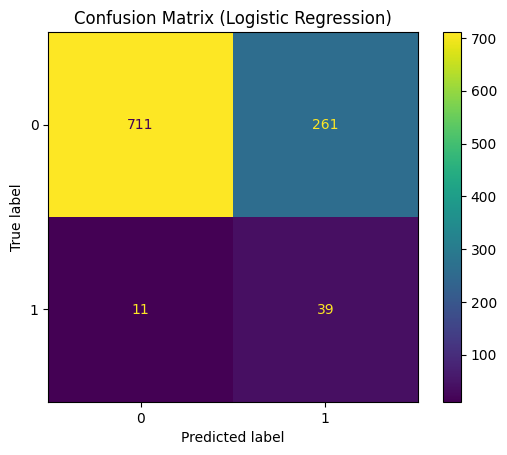

In [69]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr)
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

## Precision–Recall curve

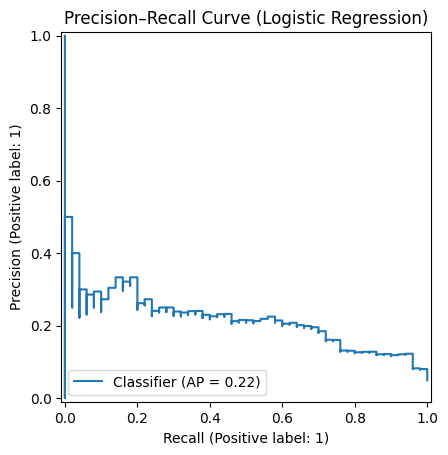

In [70]:
PrecisionRecallDisplay.from_predictions(y_test, proba_lr)
plt.title("Precision–Recall Curve (Logistic Regression)")
plt.show()

##### The logistic regression model is able to detect most stroke cases, correctly identifying 39 out of 50 patients. However, it also produces a high number of false positives, meaning many people are flagged as high risk when they are not. Overall, the model favors catching stroke cases over avoiding false alarms, which can be appropriate in a medical screening setting where missing a stroke is more serious than over-predicting risk.

## Extract feature coefficients

In [71]:
# Get feature names after preprocessing
feature_names = logreg.named_steps["preprocess"].get_feature_names_out()

# Each coefficient represents how strongly that feature influences stroke prediction.
coefficients = logreg.named_steps["model"].coef_[0]

# Create a dataframe to organize feature names and coefficients
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

# Sort features by absolute coefficient value (strongest influence first)
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient,abs_coefficient
0,num__age,1.760526,1.760526
14,cat__work_type_children,1.336981,1.336981
10,cat__work_type_Govt_job,-0.658586,0.658586
13,cat__work_type_Self-employed,-0.638809,0.638809
19,cat__smoking_status_never smoked,-0.342850,0.342850
6,cat__gender_Male,-0.279472,0.279472
17,cat__smoking_status_Unknown,-0.272684,0.272684
12,cat__work_type_Private,-0.270459,0.270459
20,cat__smoking_status_smokes,0.269281,0.269281
15,cat__Residence_type_Rural,-0.222933,0.222933


In [72]:
# Map encoded feature names back to their original columns
original_cols = num_cols + cat_cols + bin_cols

def map_to_original(feat):
    feat = feat.replace("num__", "").replace("cat__", "")
    for col in original_cols:
        if feat == col or feat.startswith(col + "_"):
            return col
    return feat

coef_df["original_feature"] = coef_df["feature"].apply(map_to_original)

In [73]:
# Aggregate the importance of encoded variables back to the original variable
feature_importance = (
    coef_df.groupby("original_feature")["abs_coefficient"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

feature_importance

,original_feature,abs_coefficient
0,work_type,2.962840
1,age,1.760526
2,smoking_status,0.942191
3,ever_married,0.288878
4,gender,0.288878
5,Residence_type,0.288878
6,avg_glucose_level,0.163385
7,hypertension,0.143703
8,bmi,0.086302
9,heart_disease,0.054927


During preprocessing, categorical variables were converted into multiple binary columns using one-hot encoding so they could be used in the logistic regression model. For example, a variable such as smoking_status was split into several encoded features like smoking_status_never, smoking_status_smokes, and smoking_status_formerly_smoked. While this is necessary for model training, it makes interpretation difficult because each category appears as a separate feature.

To properly evaluate the importance of predictors, these encoded features were grouped back to their original variables. By aggregating the coefficients of all encoded categories belonging to the same variable, we can measure the overall influence of that variable on stroke prediction. This step allows us to identify and rank the true predictors of stroke rather than interpreting each encoded category individually.

## Actionable Predictors
Age often appears as a strong predictor, but it is not directly actionable.
For intervention-focused recommendations, we exclude age and focus on modifiable or targetable factors (e.g., smoking, hypertension, glucose, etc.).

In [74]:
actionable_features = feature_importance[
    feature_importance["original_feature"] != "age"
]

top_actionable = actionable_features.head(3)
top_actionable

,original_feature,abs_coefficient
0,work_type,2.962840
2,smoking_status,0.942191
3,ever_married,0.288878


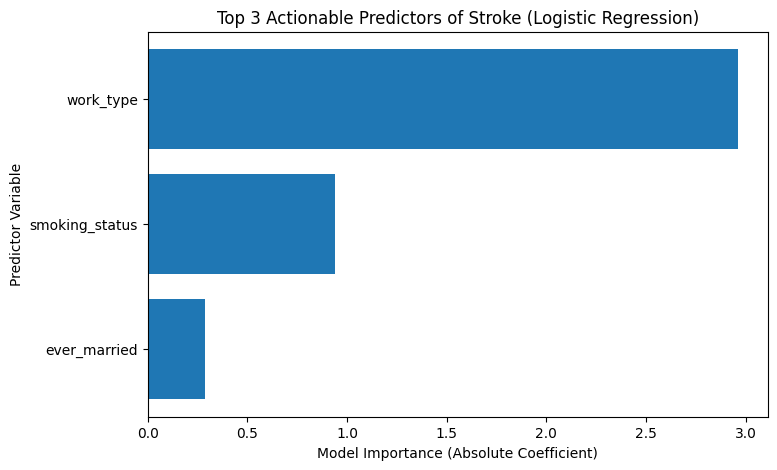

In [75]:
plt.figure(figsize=(8,5))

plt.barh(
    top_actionable["original_feature"],
    top_actionable["abs_coefficient"]
)

plt.gca().invert_yaxis()

plt.xlabel("Model Importance (Absolute Coefficient)")
plt.ylabel("Predictor Variable")
plt.title("Top 3 Actionable Predictors of Stroke (Logistic Regression)")

plt.show()

## Health vs Lifestyle Drivers
We group predictors into health-based vs lifestyle-based categories and compare their total importance to answer the business question.

In [76]:
predictor_category = {
    "age": "health",
    "hypertension": "health",
    "heart_disease": "health",
    "avg_glucose_level": "health",
    "bmi": "health",

    "smoking_status": "lifestyle",
    "work_type": "lifestyle",
    "ever_married": "lifestyle",
    "Residence_type": "lifestyle",
    "gender": "lifestyle"
}

feature_importance["category"] = feature_importance["original_feature"].map(predictor_category)
feature_importance.head()

,original_feature,abs_coefficient,category
0,work_type,2.962840,lifestyle
1,age,1.760526,health
2,smoking_status,0.942191,lifestyle
3,ever_married,0.288878,lifestyle
4,gender,0.288878,lifestyle


In [77]:
category_importance = (
    feature_importance
    .groupby("category")["abs_coefficient"]
    .sum()
    .reset_index()
)

category_importance

,category,abs_coefficient
0,health,2.208844
1,lifestyle,4.771664


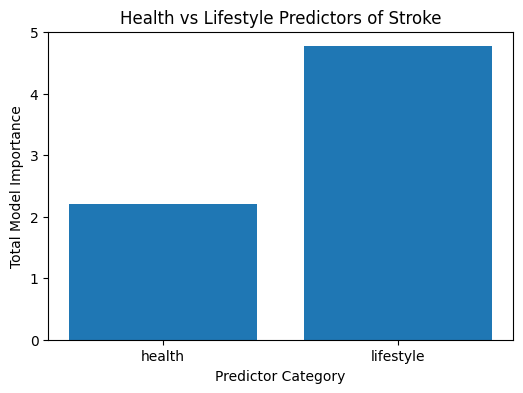

In [78]:
plt.figure(figsize=(6,4))

plt.bar(
    category_importance["category"],
    category_importance["abs_coefficient"]
)

plt.title("Health vs Lifestyle Predictors of Stroke")
plt.xlabel("Predictor Category")
plt.ylabel("Total Model Importance")

plt.show()